# Aposteriorifördelningar för härledda storheter: cykelvägen och senatsvalet

I båda exemplen i den här notebooken är det vi vill veta inte parametern själv, utan en storhet som följer av den. I det första exemplet är parametern intensiteten av cyklister på en cykelväg, medan det vi vill veta är hur många tiosekundersintervall vi måste vänta innan vi kan korsa vägen. I det andra är parametrarna andelarna bakom två kandidater i tio delstater, medan det vi vill veta är hur många mandat i USA:s senat som byter parti. I båda fallen får vi svaret genom att integrera bort parametern. Det första exemplet bygger på avsnittet om aposterioriprediktiva fördelningar i kapitel 7, det andra på avsnittet om multinomialfördelad data i kapitel 8.

Vi börjar med att importera de paket som behövs.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Cykelvägen

### Modell och aposteriorifördelning

På väg till jobbet behöver vi korsa en hårt trafikerad cykelväg. Medan vi väntar på ett mellanrum räknar vi antalet cyklister som passerar under sex tiosekundersintervall. Låt $X_i$ vara antalet cyklister under intervall $i$ och anta att
$$
\begin{split}
\Theta &\sim \mathrm{Gamma}(\alpha_0, \lambda_0), \\
X_i \mid \Theta = \theta &\sim \mathrm{Po}(\theta),
\end{split}
$$
där $X_1, \ldots, X_n$ är betingat oberoende givet $\Theta$. Vi väljer apriorifördelningens parametrar utifrån att vi väntar oss ungefär en cyklist per intervall med en standardavvikelse på en cyklist, alltså $\mathrm{E}[\Theta] = \alpha_0 / \lambda_0 = 1$ och $\mathrm{Var}[\Theta] = \alpha_0 / \lambda_0^2 = 1$, vilket ger $\alpha_0 = \lambda_0 = 1$. Uppdateringsregeln för Poissonfördelad data ger
$$
\Theta \mid \boldsymbol{X} = \boldsymbol{x} \sim \mathrm{Gamma}\Big(\alpha_0 + \sum_{i=1}^n x_i,\; \lambda_0 + n\Big).
$$

In [2]:
xs = np.array([4, 4, 1, 3, 2, 6])
n = len(xs)

alpha_0 = 1.
lam_0 = 1.

alpha_n = alpha_0 + np.sum(xs)
lam_n = lam_0 + n

print(f"Aposteriorifördelning: Gamma({alpha_n:.0f}, {lam_n:.0f})")
print(f"E[Θ | data] = {alpha_n / lam_n:.3f}")
print(f"Std[Θ | data] = {np.sqrt(alpha_n) / lam_n:.3f}")

Aposteriorifördelning: Gamma(21, 7)
E[Θ | data] = 3.000
Std[Θ | data] = 0.655


Datan flyttar parametern tydligt uppåt jämfört med vad vi trodde från början.

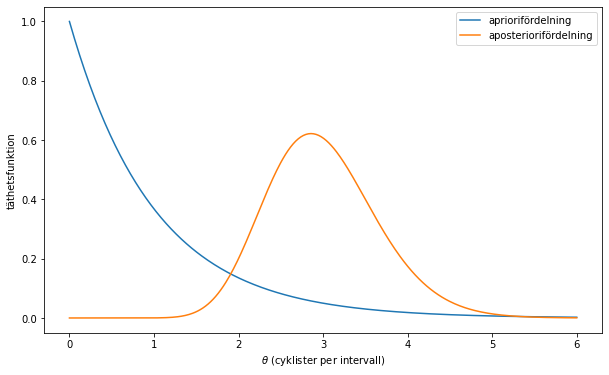

In [3]:
grid = np.linspace(0, 6, 400)

# Kursen använder intensitet λ men SciPy använder skala 1/λ.
prior = stats.gamma.pdf(grid, alpha_0, scale=1 / lam_0)
posterior = stats.gamma.pdf(grid, alpha_n, scale=1 / lam_n)

plt.figure(figsize=(10, 6))
plt.plot(grid, prior, label="apriorifördelning")
plt.plot(grid, posterior, label="aposteriorifördelning")
plt.xlabel(r"$\theta$ (cyklister per intervall)")
plt.ylabel("täthetsfunktion")
plt.legend()
plt.show()

### Nästa intervall

Låt $Y$ vara antalet cyklister under nästa intervall, med $Y \mid \Theta = \theta \sim \mathrm{Po}(\theta)$ och $Y \perp \boldsymbol{X} \mid \Theta$. Den aposterioriprediktiva fördelningen är negativt binomialfördelad,
$$
Y \mid \boldsymbol{X} = \boldsymbol{x} \sim \mathrm{NegBin}\Big(\alpha_n, \frac{\lambda_n}{\lambda_n + 1}\Big),
$$
och vi kan korsa vägen säkert om $Y = 0$.

In [4]:
# SciPy räknar antalet misslyckanden före det α_n:te lyckade försöket, vilket är
# samma parametrisering som kursens negativa binomialfördelning.
p_zero = stats.nbinom.pmf(0, alpha_n, lam_n / (lam_n + 1))

print(f"P(Y = 0 | data) = {p_zero:.4f}")

P(Y = 0 | data) = 0.0606


### Hur länge måste vi vänta?

Sannolikheten ovan är liten, så den naturliga följdfrågan är hur många intervall vi måste vänta innan ett intervall blir tomt. Låt $K$ vara det antalet, så att $K = 0$ betyder att nästa intervall redan är tomt. Givet $\Theta = \theta$ är varje intervall tomt med sannolikhet $e^{-\theta}$, oberoende av de andra, och alltså är
$$
K \mid \Theta = \theta \sim \mathrm{Geom}(e^{-\theta}), \qquad f_{K \mid \Theta}(k \mid \theta) = e^{-\theta}(1 - e^{-\theta})^k, \quad k = 0, 1, 2, \ldots
$$
Att integrera bort $\Theta$ ur täthetsfunktionen direkt är omständligt. Vi beräknar därför väntevärdet istället. Lagen om total förväntan ger $\mathrm{E}[K \mid \boldsymbol{x}] = \mathrm{E}[e^{\Theta} \mid \boldsymbol{x}] - 1$, och den resulterande gammaintegralen har sluten form:
$$
\mathrm{E}[K \mid \boldsymbol{X} = \boldsymbol{x}] = \left(\frac{\lambda_n}{\lambda_n - 1}\right)^{\alpha_n} - 1.
$$

In [5]:
mean_k = (lam_n / (lam_n - 1)) ** alpha_n - 1

print(f"E[K | data] = {mean_k:.2f} intervall, alltså omkring {10 * mean_k:.0f} sekunder")

E[K | data] = 24.46 intervall, alltså omkring 245 sekunder


### Simulering

Fördelningen kan också tas fram genom simulering, vilket är det enda praktiska alternativet så snart modellen blir lite mer komplicerad. Vi drar utfall av $\Theta$ från aposteriorifördelningen och därefter ett utfall av $K$ för varje sådant $\theta$.

In [6]:
n_samples = 10000

thetas = stats.gamma.rvs(alpha_n, scale=1 / lam_n, size=n_samples)

# SciPy:s geometriska fördelning räknar försökets nummer, alltså 1, 2, 3, ...,
# medan vårt K räknar antalet intervall vi väntar, alltså 0, 1, 2, .... Därför
# drar vi bort ett. Glömmer vi det blir alla svar en intervallängd för långa.
ks_sim = stats.geom.rvs(np.exp(-thetas)) - 1

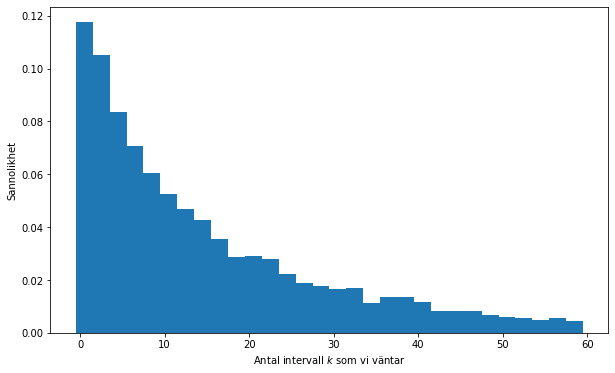

In [7]:
# K är diskret och har en lång svans. Vi ritar därför relativa frekvenser av
# hela stickprovet i staplar med bredden ett, vilket kan jämföras direkt med
# täthetsfunktionen. Med density=True skulle staplarna normeras över enbart
# det intervall som syns i figuren och därmed skalas upp.
weights = np.ones(n_samples) / n_samples

plt.figure(figsize=(10, 6))
plt.hist(ks_sim, bins=np.arange(-0.5, 60.5, 2), weights=weights)
plt.xlabel("Antal intervall $k$ som vi väntar")
plt.ylabel("Sannolikhet")
plt.show()

För att skatta väntevärdet kan vi nu ta medelvärdet av de $K$ som vi genererat. Felet i denna skattning får vi genom att skatta standardavvikelsen bland utfallen och dela med roten av antal ufall $\sqrt{n}$ (dvs. vi beräknar standardfelet). Skattning av medianen fås på samma sätt. Till slut kan vi approximera
$$
    P(K \le 6)
$$
genom att räkna antalet utfall där vi har $K \le 6$ och dela detta med det totala antalet utfall. Med andra ord så tar vi medelvärdet av vektorn som har en etta då $K \le 6$ och en nolla annars.

In [8]:
mean_sim = np.mean(ks_sim)

# Monte Carlo-standardfelet för medelvärdet.
error_sim = np.sqrt(np.mean((ks_sim - mean_sim) ** 2) / n_samples)

print(f"Simulering: medelvärde {mean_sim:.2f} ± {error_sim:.2f} (exakt {mean_k:.2f})")
print(f"Simulering: median {np.median(ks_sim):.0f}")
print(f"Simulering: P(K ≤ 6) {np.mean(ks_sim <= 6):.3f}")

Simulering: medelvärde 24.43 ± 0.41 (exakt 24.46)
Simulering: median 12
Simulering: P(K ≤ 6) 0.345


## Senatsvalet i USA 2026

I det här exemplet analyserar vi en opinionsundersökning från var och en av tio delstater där ett mandat i USA:s senat står på spel. (Totalt kommer 35 mandat att ingå i senatsvalet, men vi väljer att bara modellera tio av de mandat där det finns högst konkurrens.) För varje delstat antar vi att svaren är multinomialfördelade och lägger en likformig apriorifördelning på andelarna. Sedan beräknar vi aposteriorisannolikheten att den demokratiska kandidaten har ett större stöd än den republikanska, och sätter till sist ihop delstaterna till en simultan fördelning för hur många mandat demokraterna vinner netto.

### Modell

Vi delar in svaren i delstat $i$ i $d = 3$ kategorier: den demokratiska kandidaten, den republikanska kandidaten, och övriga eller osäkra. Låt $\boldsymbol{\Theta}_i = [\Theta_{i1}, \Theta_{i2}, \Theta_{i3}]^\mathrm{T}$ vara motsvarande andelar i väljarkåren och $\boldsymbol{X}_i$ antalet svar i varje kategori. Vi antar att
$$
\begin{split}
\boldsymbol{\Theta}_i &\sim \mathrm{Dirichlet}(1, 1, 1), \\
\boldsymbol{X}_i \mid \boldsymbol{\Theta}_i = \boldsymbol{\theta}_i &\sim \mathrm{Multi}(n_i, \boldsymbol{\theta}_i),
\end{split}
$$
där $n_i$ är antalet svarande i delstat $i$. Apriorifördelningen $\mathrm{Dirichlet}(1, 1, 1)$ är den likformiga fördelningen över de möjliga andelarna, alltså en icke-informativ apriorifördelning. Eftersom Dirichletfördelningen är konjugerad till multinomialfördelningen är aposteriorifördelningen
$$
\boldsymbol{\Theta}_i \mid \boldsymbol{X}_i = \boldsymbol{x}_i \sim \mathrm{Dirichlet}(x_{i1} + 1, x_{i2} + 1, x_{i3} + 1).
$$
De redovisade andelarna $\hat{\theta}_{ij}$ är avrundade till en decimal, så vi räknar tillbaka till antal svar med $x_{ij} = n_i \hat{\theta}_{ij}$ och accepterar att dessa tal i allmänhet inte blir heltal.

Den händelse vi är intresserade av är att den demokratiska kandidaten har ett större stöd än den republikanska, alltså $\Theta_{i1} > \Theta_{i2}$. Här utnyttjar vi en egenskap hos Dirichletfördelningen: kvoten mellan en komponent och summan av två komponenter är betafördelad, så att
$$
\frac{\Theta_{i1}}{\Theta_{i1} + \Theta_{i2}} \;\Big|\; \boldsymbol{X}_i = \boldsymbol{x}_i \sim \mathrm{Beta}(x_{i1} + 1, x_{i2} + 1).
$$
Händelsen $\Theta_{i1} > \Theta_{i2}$ är densamma som att denna kvot är större än $1/2$, och därför är
$$
\mathrm{P}(\Theta_{i1} > \Theta_{i2} \mid \boldsymbol{X}_i = \boldsymbol{x}_i) = 1 - F(1/2),
$$
där $F$ är fördelningsfunktionen för $\mathrm{Beta}(x_{i1} + 1, x_{i2} + 1)$.

### Datakällor

Varje rad är en enskild opinionsundersökning publicerad i mitten av september 2026.
Undersökningarna avser sannolika väljare (*likely voters*), inte alla röstberättigade.

| Delstat | Mätinstitut | Fältperiod | n |
|---|---|---|---|
| Iowa | Trafalgar Group | 16–18 sep. | 1089 |
| Texas | Trafalgar Group | 15–17 sep. | 1079 |
| Michigan | InsiderAdvantage | 16–18 sep. | 1200 |
| North Carolina | InsiderAdvantage | publicerad 18 sep. | 1200 |
| Georgia | Quantus Insights | 14–16 sep. | 645 |
| Alaska | co/efficient | 14–17 sep. | 799 |
| Kansas | Emerson College Polling/Nexstar | 15–16 sep. | 750 |
| Ohio (fyllnadsval) | InsiderAdvantage | 8–9 sep. | 1200 |
| Maine | YouGov | publicerad 8 sep. | 1335 |
| Florida (fyllnadsval) | St. Pete Polls | publicerad 19 sep. | 913 |

### Data

Vi lägger in en undersökning per delstat: antalet svarande och de redovisade andelarna för den demokratiska respektive den republikanska kandidaten. Resten av de svarande hamnar i kategorin övriga eller osäkra. Vi noterar också vilket parti som i dag innehar mandatet, eftersom det avgör om en demokratisk seger innebär ett nytt mandat eller ett försvarat mandat.

In [9]:
states = ["Iowa", "Texas", "Michigan", "North Carolina", "Georgia",
          "Alaska", "Kansas", "Ohio", "Maine", "Florida"]

# "R" betyder att republikanerna innehar mandatet i dag, "D" att demokraterna gör det.
incumbents = ["R", "R", "D", "R", "D", "R", "R", "R", "R", "R"]

ns = np.array([1089, 1079, 1200, 1200, 645, 799, 750, 1200, 1335, 913])
d_pcts = np.array([42.1, 46.4, 47.0, 48.4, 49.0, 46.0, 45.0, 47.0, 48.0, 45.0])
r_pcts = np.array([44.0, 45.2, 45.0, 42.5, 45.0, 48.0, 43.0, 42.0, 44.0, 45.0])

other_pcts = 100 - d_pcts - r_pcts

In [10]:
print(f"{'delstat':<16}{'parti':>6}{'n':>6}{'D (%)':>8}{'R (%)':>8}{'övr. (%)':>10}")
for i in range(len(states)):
    print(f"{states[i]:<16}{incumbents[i]:>6}{ns[i]:>6}"
          f"{d_pcts[i]:>8.1f}{r_pcts[i]:>8.1f}{other_pcts[i]:>10.1f}")

delstat          parti     n   D (%)   R (%)  övr. (%)
Iowa                 R  1089    42.1    44.0      13.9
Texas                R  1079    46.4    45.2       8.4
Michigan             D  1200    47.0    45.0       8.0
North Carolina       R  1200    48.4    42.5       9.1
Georgia              D   645    49.0    45.0       6.0
Alaska               R   799    46.0    48.0       6.0
Kansas               R   750    45.0    43.0      12.0
Ohio                 R  1200    47.0    42.0      11.0
Maine                R  1335    48.0    44.0       8.0
Florida              R   913    45.0    45.0      10.0


### Aposteriorifördelning per delstat

Vi räknar först om de redovisade andelarna till antal svar i varje kategori och adderar apriorifördelningens parametrar. Att apriorifördelningen är $\mathrm{Dirichlet}(1, 1, 1)$ motsvarar alltså att vi lägger till en pseudoobservation i varje kategori.

In [11]:
counts_d = ns * d_pcts / 100
counts_r = ns * r_pcts / 100
counts_other = ns * other_pcts / 100

# Aposteriorifördelningens parametrar, en per kategori och delstat.
alpha_d = counts_d + 1
alpha_r = counts_r + 1
alpha_other = counts_other + 1
alpha_sum = alpha_d + alpha_r + alpha_other

Aposterioriväntevärdet för andelen i kategori $j$ är $\alpha_{ij} / \alpha_{i0}$, där $\alpha_{i0} = \alpha_{i1} + \alpha_{i2} + \alpha_{i3}$. Sannolikheten att den demokratiska kandidaten leder får vi ur betafördelningen enligt ovan. Vi kan också simulera fram denna sannolikhet om vi vill.

In [12]:
post_d = alpha_d / alpha_sum
post_r = alpha_r / alpha_sum

# stats.beta.sf(0.5, a, b) är 1 - F(0.5), alltså sannolikheten att en
# betafördelad variabel är större än 0.5.
p_d_leads = 1 - stats.beta.cdf(0.5, alpha_d, alpha_r)

Vi samlar resultaten i en tabell, uttryckta i procent respektive procentenheter, och sorterar delstaterna efter sannolikheten att den demokratiska kandidaten leder.

In [13]:
# np.argsort ger de index som sorterar arrayen i stigande ordning. Vi vänder på
# ordningen med [::-1] för att få den mest sannolika delstaten först.
order = np.argsort(p_d_leads)[::-1]

print(f"{'delstat':<16}{'parti':>6}{'D (%)':>8}{'R (%)':>8}"
      f"{'P(D > R)':>10}")
for i in order:
    print(f"{states[i]:<16}{incumbents[i]:>6}{100 * post_d[i]:>8.1f}{100 * post_r[i]:>8.1f}"
          f"{p_d_leads[i]:>10.3f}")

delstat          parti   D (%)   R (%)  P(D > R)
North Carolina       R    48.4    42.5     0.984
Ohio                 R    47.0    42.0     0.967
Maine                R    48.0    44.0     0.936
Georgia              D    48.9    44.9     0.852
Michigan             D    47.0    45.0     0.765
Kansas               R    45.0    43.0     0.720
Texas                R    46.4    45.2     0.660
Florida              R    45.0    45.0     0.500
Alaska               R    46.0    47.9     0.280
Iowa                 R    42.1    44.0     0.250


Samma sannolikheter som en figur. Blå staplar är mandat som demokraterna innehar i dag, röda staplar mandat som republikanerna innehar. Den streckade linjen markerar sannolikheten $0.5$, där de två kandidaterna är jämna.

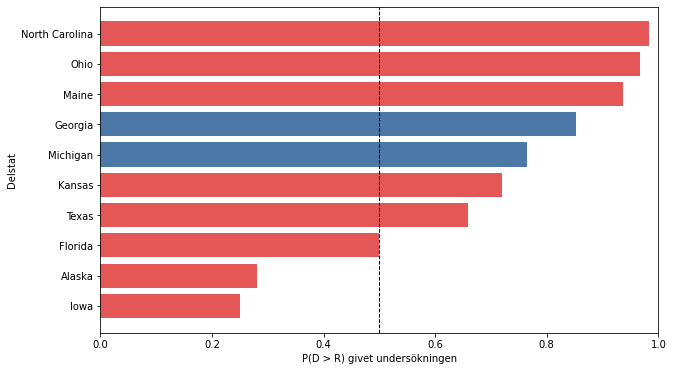

In [14]:
# Liggande staplar ritas nedifrån och upp, så vi sorterar i stigande ordning för
# att få den mest sannolika delstaten överst.
plot_order = np.argsort(p_d_leads)
colors = ["#4C78A8" if incumbents[i] == "D" else "#E45756" for i in plot_order]

plt.figure(figsize=(10, 6))
plt.barh([states[i] for i in plot_order], p_d_leads[plot_order], color=colors)
plt.axvline(0.5, color="black", linewidth=1, linestyle="--")
plt.xlim(0, 1)
plt.xlabel("P(D > R) givet undersökningen")
plt.ylabel("Delstat")
plt.show()

### Simultan fördelning för mandatnettot

Senaten består i dag av 53 republikanska mandat och 47 mandat som tillhör demokraterna eller röstar med dem. Demokraterna behöver alltså ett nettotillskott på minst fyra mandat för att nå 51. I en delstat där republikanerna innehar mandatet ger en demokratisk seger $+1$, och i en delstat där demokraterna innehar mandatet ger en demokratisk förlust $-1$. Övriga mandat i senaten står inte på spel här och antas ligga fast.

Vi antar nu att de tio valutgångarna är betingat oberoende givet undersökningarna. Då kan vi bygga upp fördelningen för nettot genom att lägga till en delstat i taget: för varje delstat fördelar vi den sannolikhetsmassa som ligger på ett visst netto över de två möjliga utfallen. Detta är samma sak som att *falta* de tio fördelningarna med varandra.

In [15]:
# Fördelningen sparas som en dictionary med nettotillskottet som key och
# sannolikheten som value. Vi utgår från nettot noll med sannolikhet ett.
net_dist = {0: 1.}

for i in range(len(states)):
    p = p_d_leads[i]

    if incumbents[i] == "R":
        # Demokraterna kan vinna ett mandat här, men inte förlora något.
        increments = {1: p, 0: 1 - p}
    else:
        # Demokraterna kan förlora ett mandat här, men inte vinna något.
        increments = {0: p, -1: 1 - p}

    updated = {}
    for net, prob in net_dist.items():
        for increment, increment_prob in increments.items():
            new_net = net + increment
            # Om sannolikheten för new_net inte finns, sätt den till noll.
            updated[new_net] = updated.get(new_net, 0) + prob * increment_prob

    net_dist = updated

In [16]:
# Notera: metoden `sorted` extraherar nycklarna och sorterar dem.
net_gains = np.array(sorted(net_dist))
net_probs = np.array([net_dist[net] for net in net_gains])

p_majority = np.sum(net_probs[net_gains >= 4])

print(f"P(nettotillskott ≥ 4 | data): {p_majority:.3f}")

P(nettotillskott ≥ 4 | data): 0.880


In [17]:
print(f"{'nettotillskott':<16}{'sannolikhet':>14}")
for net, prob in zip(net_gains, net_probs):
    print(f"{net:<16}{prob:>14.4f}")

nettotillskott     sannolikhet
-2                      0.0000
-1                      0.0000
0                       0.0001
1                       0.0025
2                       0.0213
3                       0.0955
4                       0.2370
5                       0.3240
6                       0.2319
7                       0.0779
8                       0.0096


Hela fördelningen som en figur, med gränsen för majoritet markerad.

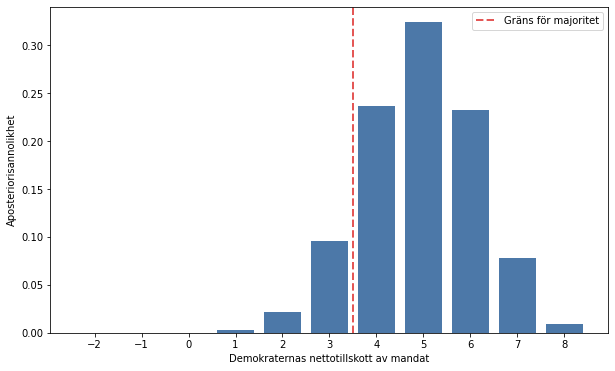

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(net_gains, net_probs, color="#4C78A8")
plt.axvline(3.5, color="#E45756", linewidth=2, linestyle="--", label="Gräns för majoritet")
plt.xticks(net_gains)
plt.xlabel("Demokraternas nettotillskott av mandat")
plt.ylabel("Aposteriorisannolikhet")
plt.legend()
plt.show()